# Question 1
Neuron Network is a model that represents and mimics human's brain. It learns patterns from data using layers of nodes. The result goes through an activation function to decide the output. A Neuron Network typically has 3 layers: input layers(raw data), hidden layers(fine-tune the results until the error is minimized), and output(final result).

General steps to build this is to define the problem that have to be solve, and expecting what input and output should be like. Then prepare and collect useful data, which including clean, split into training, ect. After that, we have to design and plan the layers(simulate the human's thinking process) that required. After that, each neuron will be apply to an activation function. Next step is to use forward/backward propagation to check the prediction and the efficiency of input data when go through each layer. Lastly, repeat the training and tune based on performance. 

# Question 2
We can check the performance of a Neural Network by running the trained model on data it has never seen during training (test set) to measure how well its predictions match the true labels using accuracy/recall. This is the case because neural network model requires measuring performance on unseen data, not just training dataset alone, and this also prevent model overfitting.

# Question 3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

credit_df = pd.read_csv('credit_card.csv')
credit_df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2


In [ ]:
def encode_to_numbers(credit_df):
    credit_df['Car_Owner'] = credit_df['Car_Owner'].map({'Y': 1, 'N': 0})
    credit_df['Propert_Owner'] = credit_df['Propert_Owner'].map({'Y': 1, 'N': 0})
    credit_df['GENDER'] = credit_df['GENDER'].map({'M': 1, 'F': 0})

    cols = ['Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type', 'Type_Occupation']
    le = LabelEncoder()
    for col in cols:
        credit_df[col] = le.fit_transform(credit_df[col].astype(str))
    return credit_df

def handle_value(credit_df):
    credit_df = credit_df.copy()
    credit_df = credit_df.fillna(credit_df.median(numeric_only=True))
    credit_df['Birthday_count'] = (-credit_df['Birthday_count']) / 365
    credit_df['Employed_days'] = credit_df['Employed_days'].replace(365243, 0)
    credit_df['Employed_days'] = (-credit_df['Employed_days']) / 365
    return credit_df

def run(credit_df):
    credit_df = handle_value(credit_df)
    credit_df = encode_to_numbers(credit_df)
    return credit_df

result = run(credit_df)
result['Annual_income'] = result['Annual_income'].fillna(result['Annual_income'].median())
result['GENDER'] = result['GENDER'].fillna(result['GENDER'].median())
result['Birthday_count'] = result['Birthday_count'].fillna(result['Birthday_count'].median())
result.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,1.0,1,1,0,180000.0,1,1,1,1,51.430137,0.000000,1,0,0,0,18,2
1,5009744,0.0,1,0,0,315000.0,0,1,1,1,37.142466,1.605479,1,1,1,0,18,2
2,5009746,0.0,1,0,0,315000.0,0,1,1,1,42.908219,1.605479,1,1,1,0,18,2
3,5009749,0.0,1,0,0,166500.0,0,1,1,1,37.142466,1.605479,1,1,1,0,18,2
4,5009752,0.0,1,0,0,315000.0,0,1,1,1,37.142466,1.605479,1,1,1,0,18,2


For this dataset, I have clean more columns instead of just remove most of the columns, like Birthday_count, or Employed_days. I also try to encode all of the columnd, and filled NaN with median values from each column.

# Question 4

In [41]:
import torch

from sklearn.model_selection import train_test_split

drop_cols = ['Ind_ID', 'Mobile_phone', 'Work_Phone', 'Phone', 'EMAIL_ID', "CHILDREN"]
result['High_Income'] = (result['Annual_income'] > result['Annual_income'].median()).astype(int)

X = result.drop(drop_cols, axis=1).values
y = result['High_Income'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42,
                                                    stratify=y)

In [42]:
import torch.nn as nn
import torch.nn.functional as F  

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_test = torch.LongTensor(y_test)
y_train = torch.LongTensor(y_train)

print(X_train)

tensor([[ 1.,  0.,  1.,  ...,  2.,  1.,  0.],
        [ 0.,  0.,  1.,  ...,  3.,  2.,  0.],
        [ 0.,  0.,  0.,  ...,  2.,  2.,  0.],
        ...,
        [ 0.,  0.,  1.,  ..., 18.,  2.,  0.],
        [ 0.,  0.,  0.,  ..., 18.,  2.,  0.],
        [ 0.,  1.,  0.,  ...,  8.,  2.,  0.]])


In [43]:
class ANN_Model(nn.Module):
    def __init__(self, input_features=13,
                 hidden1=20, hidden2=20,
                 out_features=2):
        super().__init__()
    
        self.layer_1_connection = nn.Linear(input_features, hidden1)
        self.layer_2_connection = nn.Linear(hidden1, hidden2)
        self.out = nn.Linear(hidden2, out_features)

    def forward(self, x):
        # apply activation function
        x = F.relu(self.layer_1_connection(x))
        x = F.relu(self.layer_2_connection(x))
        x = self.out(x)
        return x

In [50]:
torch.manual_seed(42)
ann = ANN_Model()

In [45]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(ann.parameters(), lr=0.01)

In [46]:
final_loss = []
n_epochs = 500
for epoch in range(n_epochs):
    y_pred = ann.forward(X_train)
    loss = loss_function(y_pred, y_train)
    final_loss.append(loss)

    if epoch % 10 == 1:
        print(f'Epoch number: {epoch} with loss {loss}')

    optimizer.zero_grad()  
    loss.backward()        
    optimizer.step()       

Epoch number: 1 with loss 1618.9017333984375
Epoch number: 11 with loss 189.00234985351562
Epoch number: 21 with loss 327.4104919433594
Epoch number: 31 with loss 157.07174682617188
Epoch number: 41 with loss 64.69815063476562
Epoch number: 51 with loss 229.07537841796875
Epoch number: 61 with loss 51.723480224609375
Epoch number: 71 with loss 69.28563690185547
Epoch number: 81 with loss 49.95338439941406
Epoch number: 91 with loss 32.882938385009766
Epoch number: 101 with loss 22.457006454467773
Epoch number: 111 with loss 21.08510971069336
Epoch number: 121 with loss 12.990707397460938
Epoch number: 131 with loss 13.39726734161377
Epoch number: 141 with loss 39.32762145996094
Epoch number: 151 with loss 4.474894046783447
Epoch number: 161 with loss 8.422179222106934
Epoch number: 171 with loss 12.136916160583496
Epoch number: 181 with loss 31.303680419921875
Epoch number: 191 with loss 8.677218437194824
Epoch number: 201 with loss 46.645992279052734
Epoch number: 211 with loss 17.141

In [47]:
y_pred = []

with torch.no_grad():  
    for i, data in enumerate(X_test):
        prediction = ann(data)
        y_pred.append(prediction.argmax())

ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (467).

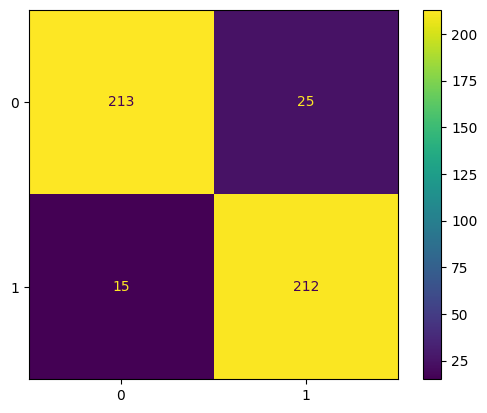

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [49]:
# Recall
212/(212+15)

0.933920704845815

The Recall is not entirely accurate because for this dataset, I assume that annual income > median annual income will be classified as high income, which is an artificial threshold and may not reflect true real-world classification. Overall, the model is learning well, but the fluctuating loss means it still needs stabilization and better tuning. 

# Question 4

I think the neural network is able to learn patterns from the dataset and its loss decreases over time, which shows that it is learning, but it is also slightly unstable due to fluctuations during training and the need for tuning such as scaling and proper hyperparameters. I believe that compared to other possible models like Logistic Regression or Random Forest, those traditional models would likely perform better or at least more consistently on this dataset because it is structured tabular data with a relatively small size, which they handle very well without requiring heavy tuning. I think the neural network could potentially perform better with more data and better optimization, but in this case, I believe simpler models are more reliable and stable for prediction.